In [1]:
import pandas as pd
from src.common.utils import get_root_directory
import matplotlib.pyplot as plt
from src.preprocessing.data_loader import DataLoader

## Walkforward Sliding-Window

In [2]:
root_dir = get_root_directory()
DL = DataLoader(root_dir)
DL.load_data()
selected_features = ['ETH_D_AvgPrc', 'ETH_YF_Hi', 'ETH_YF_Lo']
DL.select_features(features=selected_features)
DL.set_time_range(start_date="01/01/2021", end_date="31/12/2023")
train, test = DL.split_data(split_size=0.15)
train, val = DL.split_data(split_type="train_val", split_size=0.15)
n_periods=7

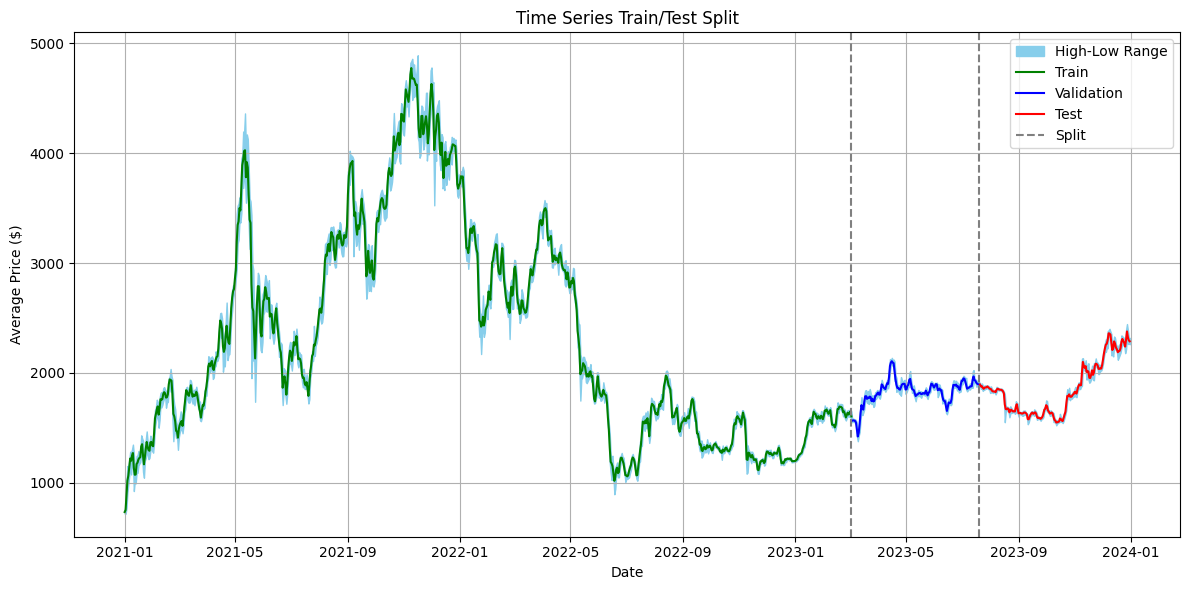

In [3]:
plt.figure(figsize=(12, 6))
plt.fill_between(DL.final_data.index, DL.final_data['ETH_YF_Hi'], DL.final_data['ETH_YF_Lo'], color='skyblue', label='High-Low Range')
plt.plot(train.index, train['ETH_D_AvgPrc'].values, label='Train', color='green')
plt.plot(val.index, val['ETH_D_AvgPrc'].values, label='Validation', color='blue')
plt.plot(test.index, test['ETH_D_AvgPrc'].values, label='Test', color='red')
plt.axvline(train.index[-1], color='gray', linestyle='--', label='Split')
plt.axvline(val.index[-1], color='gray', linestyle='--')
plt.title('Time Series Train/Test Split')
plt.xlabel('Date')
plt.ylabel('Average Price ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()